<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/Module3_Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 3

1.  Task 1:Load Image
2.  Task 2:Convert from RGB to grayscale
3.  Task 3:Apply threeshold for image
4.  Task 4:Label the regions
5.  Task 5:Extract regional properties
6.  Task 6:Show the sccaterplot the features
7.  Task 7:Find balloons as objects with area higher than 500 and eccentricity lower than 0.8
8.  Task 8:Plot the baloons

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_3639/887634856.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(img)


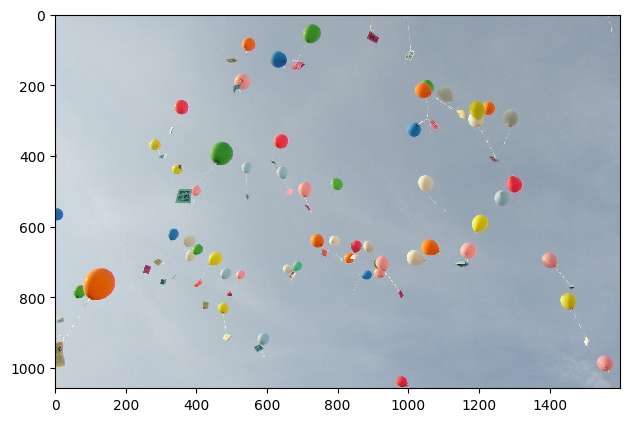

In [83]:
import skimage as sk
from skimage import io
from google.colab import drive
drive.mount('/content/drive')
img=sk.io.imread("/content/drive/MyDrive/Colab Notebooks/baloons.jpg")
sk.io.imshow(img)


/tmp/ipykernel_3639/2819685403.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(img_gray)


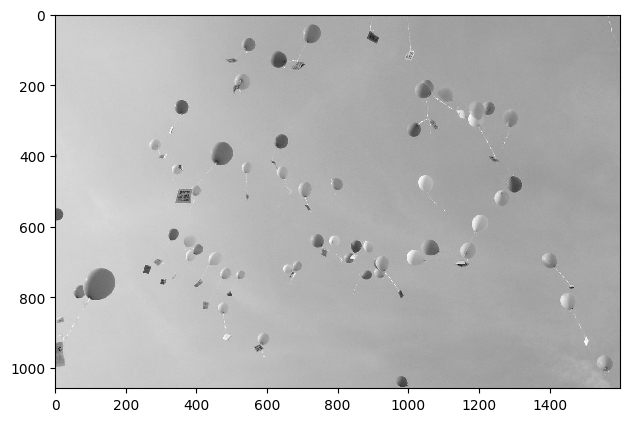

In [84]:
from skimage.color import rgb2gray
img_gray=rgb2gray(img)
sk.io.imshow(img_gray)

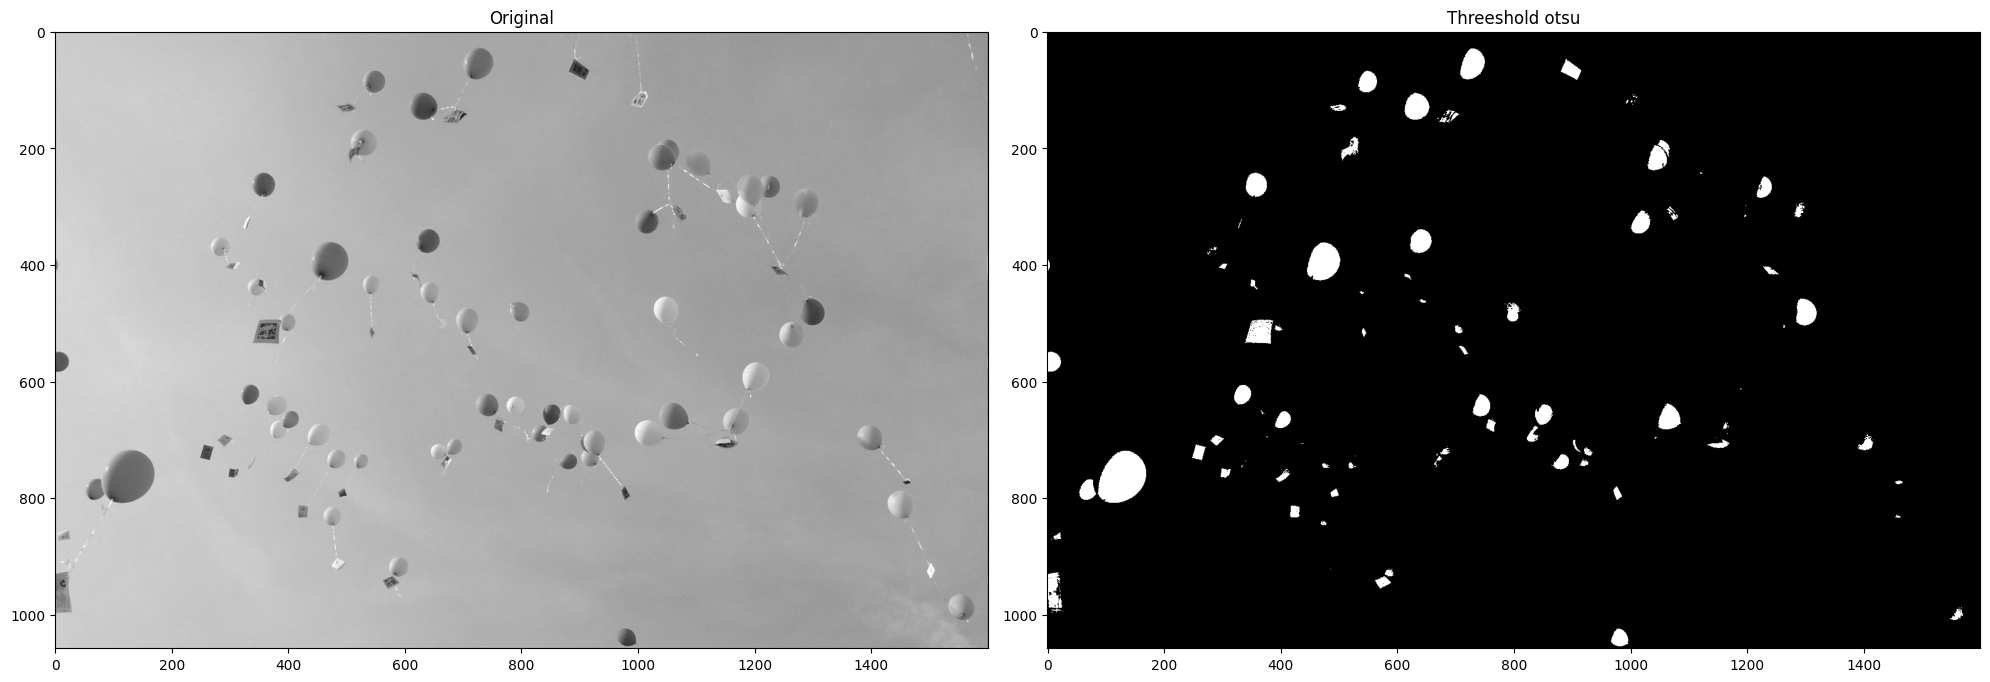

In [85]:
from skimage.filters import threshold_otsu, gaussian
import matplotlib.pyplot as plt
import numpy as np
gamma = 0.5
img_gamma = img_gray ** gamma
background = gaussian(img_gamma, sigma=50)
img_corrected = img_gamma / (background + 1e-6)
threshold = threshold_otsu(img_corrected)
img_binary = img_corrected < threshold
fig, axes = plt.subplots(1, 2, figsize=(20,  10))
axes[0].imshow(img_gray, cmap=plt.cm.gray)
axes[0].set_title("Original")
axes[1].imshow(img_binary, cmap=plt.cm.gray)
axes[1].set_title("Threeshold otsu")
plt.tight_layout()
plt.show()

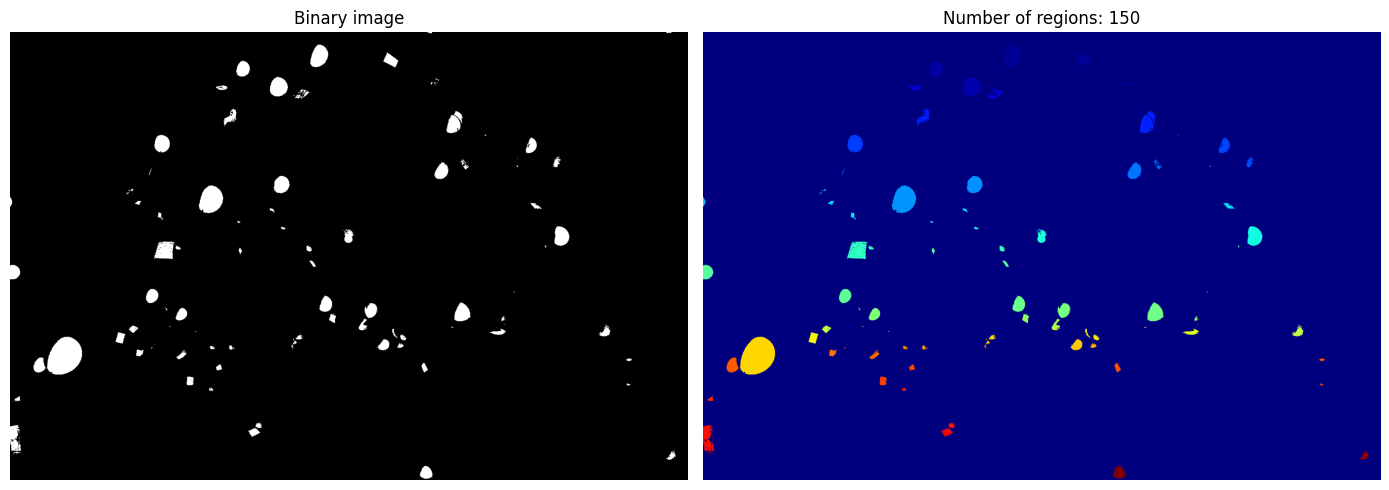

In [86]:
from skimage.filters import threshold_otsu
from skimage.measure import label
import matplotlib.pyplot as plt
import numpy as np
label_image, nregions = label(img_binary, return_num=True)
label_image = label_image.astype(np.int16)
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(img_binary, cmap='gray')
ax[0].set_title('Binary image')
ax[1].imshow(label_image, cmap='jet')
ax[1].set_title(f'Number of regions: {nregions}')
ax[0].axis('off')
ax[1].axis('off')
plt.tight_layout()
plt.show()

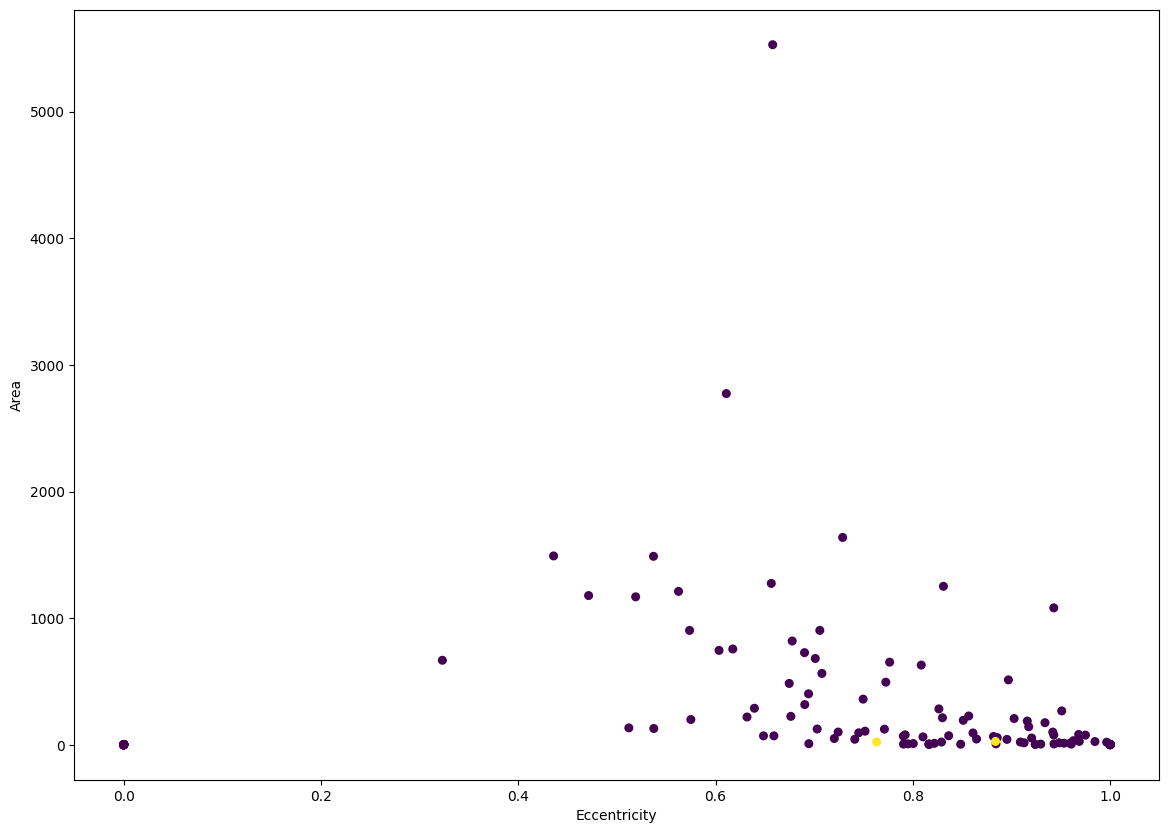

In [87]:
from skimage.measure import regionprops
import numpy as np
import matplotlib.pyplot as plt
props = regionprops(label_image)
features = np.zeros((len(props), 3))
labels = np.zeros(len(props))
bw1 = (img[:, :, 0] == 0).astype(np.uint8)
bw2 = (img[:, :, 2] == 0).astype(np.uint8)
for i, prop in enumerate(props):
    features[i, 0] = prop.eccentricity
    features[i, 1] = prop.area
    features[i, 2] = prop.solidity
    row, col = map(int, prop.centroid)
    row = np.clip(row, 0, bw1.shape[0] - 1)
    col = np.clip(col, 0, bw1.shape[1] - 1)
    labels[i] = bw1[row, col] + 2 * bw2[row, col]
plt.figure(figsize=(14, 10))
plt.scatter(features[:, 0], features[:, 1], s=30, c=labels, marker='o')
plt.xlabel('Eccentricity')
plt.ylabel('Area')
plt.show()

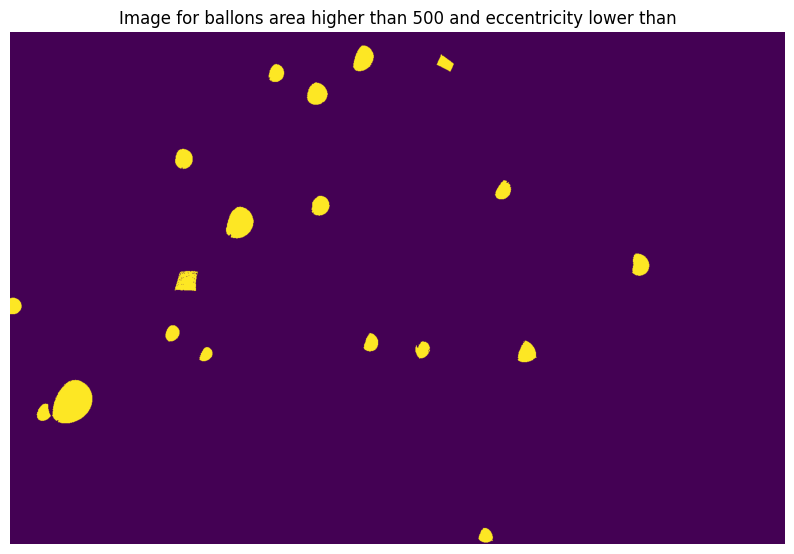

In [88]:
from skimage.measure import regionprops
import numpy as np
import matplotlib.pyplot as plt
props = regionprops(label_image)
mask = np.zeros(label_image.shape, dtype=bool)
for prop in props:
    area = prop.area
    eccentricity = prop.eccentricity
    if area > 500 and eccentricity < 0.8:
        mask[label_image == prop.label] = True
axes[0].imshow(img)
axes[1].imshow(mask)
plt.figure(figsize=(10, 8))
plt.imshow(mask)
plt.title("Image for ballons area higher than 500 and eccentricity lower than")
plt.axis('off')
plt.show()

In [89]:
from skimage.measure import regionprops
import numpy as np
props = regionprops(label_image)
balloon_regions = []
for i, prop in enumerate(props):
    area = prop.area
    eccentricity = prop.eccentricity
    if area > 500 and eccentricity < 0.8:
        balloon_regions.append(prop.label)
balloon_regions = np.array(balloon_regions)
print(balloon_regions)

[  3   4   5   6  28  36  40  41  56  62  69  70  72  73  74  76 102 122
 150]
